In [3]:
train_file_path = r"C:\Users\Lenovo\Desktop\END-END-MACHINELEARNINGPROJECT\End-End-MachineLearning_Project\housing\artifact\ingested_dir\2023-03-30_12-12-33\ingested_data\train\housing.csv"
test_file_path = r"C:\Users\Lenovo\Desktop\END-END-MACHINELEARNINGPROJECT\End-End-MachineLearning_Project\housing\artifact\ingested_dir\2023-03-30_12-12-33\ingested_data\test\housing.csv"

In [5]:
import pandas as pd
df = pd.read_csv(train_file_path)

In [6]:
df.head()

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
1,15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2,2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
3,14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
4,20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


In [8]:
df["median_house_value"]

0         72100.0
1        279600.0
2         82700.0
3        112500.0
4        238300.0
           ...   
16507    268500.0
16508     90400.0
16509    140400.0
16510    258100.0
16511     62700.0
Name: median_house_value, Length: 16512, dtype: float64

In [30]:
x,y = df.drop(columns=["median_house_value","Unnamed: 0"],axis=1),df[["median_house_value"]]

In [31]:
x.shape

(16512, 9)

In [32]:
y.shape

(16512, 1)

In [34]:
x.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        158
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [35]:
from sklearn.impute import SimpleImputer

In [36]:
numerical_columns = x.drop(columns=["ocean_proximity"],axis=1)

In [37]:
simple_imputer = SimpleImputer(strategy="median")

In [38]:
simple_imputer.fit_transform(numerical_columns)

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]])

In [39]:
simple_imputer.transform(numerical_columns)

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]])

In [40]:
simple_imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [41]:
simple_imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [43]:
x.latitude.median()

34.26

In [45]:
df.ocean_proximity.value_counts()

<1H OCEAN     7277
INLAND        5262
NEAR OCEAN    2124
NEAR BAY      1847
ISLAND           2
Name: ocean_proximity, dtype: int64

In [47]:
simple_imputer = SimpleImputer(strategy="most_frequent")
simple_imputer.fit_transform([df.ocean_proximity])

array([['INLAND', 'NEAR OCEAN', 'INLAND', ..., '<1H OCEAN', '<1H OCEAN',
        'INLAND']], dtype=object)

In [48]:
simple_imputer.statistics_

array(['INLAND', 'NEAR OCEAN', 'INLAND', ..., '<1H OCEAN', '<1H OCEAN',
       'INLAND'], dtype=object)

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [78]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [85]:
num_pipeline = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaling",StandardScaler(with_mean=False))
])

In [86]:
cat_pipeline = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehotencoding",OneHotEncoder()),
    ("scaler",StandardScaler(with_mean=False))
])

In [87]:
num_column_name = ['longitude', 'latitude', 'housing_median_age',
       'total_rooms', 'total_bedrooms', 'population', 'households',
       'median_income']

cat_column_name = ['ocean_proximity']       

In [88]:
preprocessor = ColumnTransformer([
    ("num_pipeline",num_pipeline,num_column_name),
    ("cat_pipeline",cat_pipeline,cat_column_name)]
)

In [89]:
# df = df.drop(["Unnamed: 0"],axis=1)

In [108]:
train_df = preprocessor.fit_transform(df)

In [125]:
test_df = pd.read_csv(test_file_path)
test_df

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN
1,17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN
2,3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN
3,7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN
4,14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...,...
4123,12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,110000.0,<1H OCEAN
4124,7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,118800.0,<1H OCEAN
4125,17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,293800.0,<1H OCEAN
4126,10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,335700.0,<1H OCEAN


In [126]:
test_df =test_df.drop(columns=["Unnamed: 0"],axis=1)

In [127]:
test_df = preprocessor.transform(test_df)

In [99]:
import dill


In [102]:
with open("preprocessing_obj","wb") as pkl_obj:

    dill.dump(preprocessor,pkl_obj)

In [103]:
with open("preprocessing_obj","rb") as pkl_obj:
    data = dill.load(pkl_obj)

In [130]:
test_df

array([[-59.14273417,  15.95960092,   2.30626612, ...,   0.        ,
          0.        ,   0.        ],
       [-60.15683798,  16.31976777,   1.90863403, ...,   0.        ,
          0.        ,   0.        ],
       [-59.17270768,  16.02040831,   2.86295105, ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [-59.80714701,  16.10928065,   3.41963598, ...,   0.        ,
          0.        ,   0.        ],
       [-58.90294608,  15.73040384,   2.38579254, ...,   0.        ,
          0.        ,   0.        ],
       [-59.22765912,  15.99234336,   2.86295105, ...,   0.        ,
          0.        ,   0.        ]])

In [129]:
test_df= data.transform(test_df)

ValueError: X has 13 features, but ColumnTransformer is expecting 10 features as input.

In [135]:
import numpy as np
x = test_df
y = np.array(df.median_house_value)

In [136]:
from sklearn.linear_model import LinearRegression

In [137]:
lr = LinearRegression()
lr.fit(x,y)

ValueError: Found input variables with inconsistent numbers of samples: [4128, 16512]

In [138]:
y_hat = lr.predict()

NotFittedError: This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

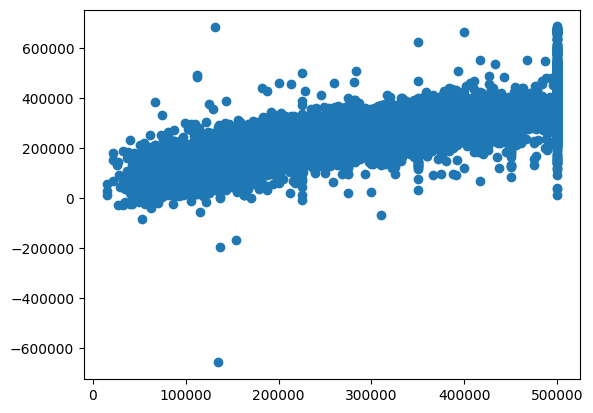

In [118]:
import matplotlib.pyplot as plt
plt.plot(y,y_hat,"o")

In [119]:
from sklearn.metrics import r2_score

r2_score(y,y_hat)

0.6438078978089459

In [ ]:
y_hat_test = 